# GPPlus Basic Usage

In [ ]:
# Import needed libraries
import gpytorch
import matplotlib.pyplot as plt
import torch

import gpplus

## 1. Define a toy dataset

In [6]:
train_x = torch.linspace(0, 1, 10)
train_y = torch.sin(train_x * (2 * torch.pi)) + 0.1 * torch.randn(train_x.size())

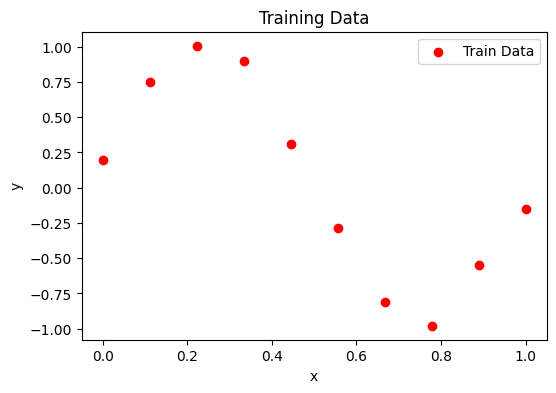

In [7]:
# Plot the training data
plt.figure(figsize=(6, 4))
plt.scatter(train_x.numpy(), train_y.numpy(), color="red", label="Train Data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Training Data")
plt.legend()
plt.show()

## 2. Define the GP model and likelihood

In [8]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = gpplus.models.GPR(train_x, train_y, likelihood)

## 3. Train the model

Iter 10/50 - Loss: 0.867
Iter 20/50 - Loss: 0.616
Iter 30/50 - Loss: 0.364
Iter 40/50 - Loss: 0.153
Iter 50/50 - Loss: 0.003


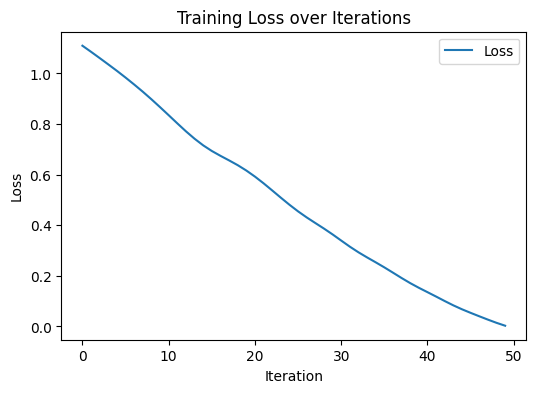

In [9]:
training_iter = 50
model.train()
likelihood.train()

optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

losses = []
for i in range(training_iter):
    optimizer.zero_grad()
    output = model(train_x)
    loss = -mll(output, train_y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (i + 1) % 10 == 0:
        print(f"Iter {i + 1}/{training_iter} - Loss: {loss.item():.3f}")

# Plot training loss
plt.figure(figsize=(6, 4))
plt.plot(range(training_iter), losses, label="Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss over Iterations")
plt.legend()
plt.show()

## 4. Evaluate (testing phase)

In [10]:
model.eval()
likelihood.eval()

test_x = torch.linspace(0, 1, 51)
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred = likelihood(model(test_x))
    mean = pred.mean
    lower, upper = pred.confidence_region()

## 5. Plot predictions

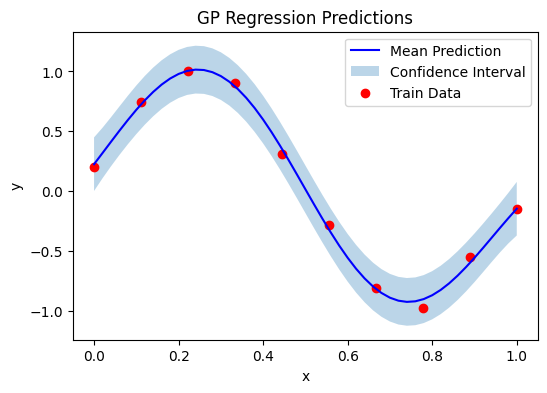


Sample Predictions:
x = 0.000 | mean = 0.225 | lower = 0.001 | upper = 0.449
x = 0.200 | mean = 0.979 | lower = 0.777 | upper = 1.180
x = 0.400 | mean = 0.597 | lower = 0.398 | upper = 0.797
x = 0.600 | mean = -0.557 | lower = -0.756 | upper = -0.358
x = 0.800 | mean = -0.870 | lower = -1.071 | upper = -0.668
x = 1.000 | mean = -0.147 | lower = -0.371 | upper = 0.077


In [11]:
plt.figure(figsize=(6, 4))
plt.plot(test_x.numpy(), mean.numpy(), "b", label="Mean Prediction")
plt.fill_between(test_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.3, label="Confidence Interval")
plt.scatter(train_x.numpy(), train_y.numpy(), color="red", label="Train Data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("GP Regression Predictions")
plt.legend()
plt.show()

# Print sample predictions
print("\nSample Predictions:")
for i in range(0, len(test_x), 10):
    print(
        f"x = {test_x[i].item():.3f} | mean = {mean[i].item():.3f} | "
        f"lower = {lower[i].item():.3f} | "
        f"upper = {upper[i].item():.3f}"
    )